In [28]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from skimage.color import rgb2lab, lab2rgb
from skimage.transform import resize


MODEL_PATH = 'Colorized-Img/Colorized-Img/Colorized-Img/colorize_autoencoder_first1000.keras'
image_paths = [
    'Colorized-Img/Colorized-Img/forest.397.jpg',
    'Colorized-Img/Colorized-Img/forest.399.jpg',
    'Colorized-Img/Colorized-Img/YIN8QU2CC97X.jpg',
    'Colorized-Img/Colorized-Img/ZYLOMHW6DWLE.jpg'
]


model = tf.keras.models.load_model(MODEL_PATH)
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 2)    │         1,154 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 9,310,408 (35.52 MB)

 Trainable params: 3,102,530 (11.84 MB)

 Non-trainable params: 2,816 (11.00 KB)

 Optimizer params: 6,205,062 (23.67 MB)

## 2. 

In [29]:
method_1_L_channels = []
method_2_L_channels = []

for path in image_paths:
# --- Method 1 ---
    gray_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    gray_res = cv2.resize(gray_img, (256, 256))
    rgb_like = np.stack([gray_res] * 3, axis=-1) / 255.0 # Channel iteration and normalization
    lab_1 = rgb2lab(rgb_like)
    L1 = lab_1[:, :, 0]
    L1_final = L1[:, :, np.newaxis] # Convert dimensions to (256, 256, 1)
    method_1_L_channels.append(L1_final)

    # --- Method 2 ---
    bgr_img = cv2.imread(path, cv2.IMREAD_COLOR)
    bgr_res = cv2.resize(bgr_img, (256, 256))
    rgb_img = cv2.cvtColor(bgr_res, cv2.COLOR_BGR2RGB) / 255.0
    lab_2 = rgb2lab(rgb_img)
    L2 = lab_2[:, :, 0]
    L2_final = L2[:, :, np.newaxis] # Convert dimensions to (256, 256, 1)
    method_2_L_channels.append(L2_final)

    X_method_1 = np.array(method_1_L_channels)
    X_method_2 = np.array(method_2_L_channels)

print("Dimensions of method 1 data:", X_method_1.shape)
print("Dimensions of method 2 data:", X_method_2.shape)

Dimensions of method 1 data: (4, 256, 256, 1)
Dimensions of method 2 data: (4, 256, 256, 1)


# 3.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


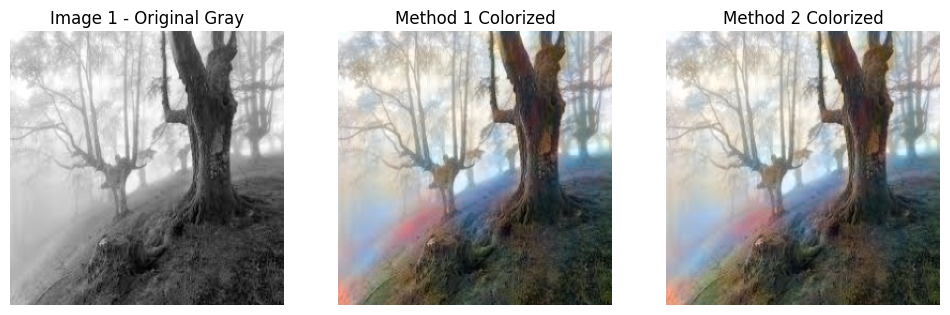

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


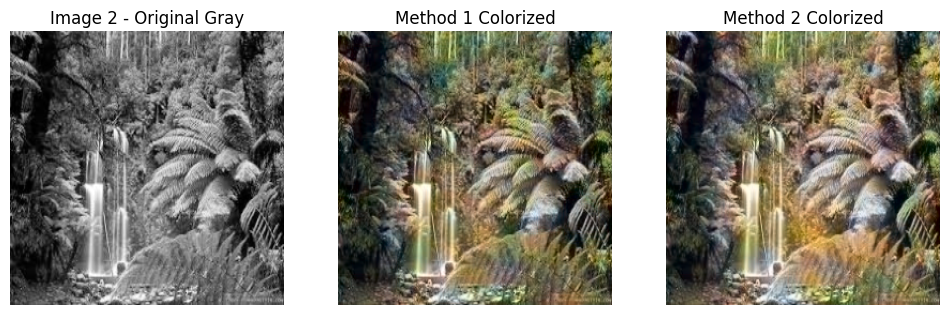

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


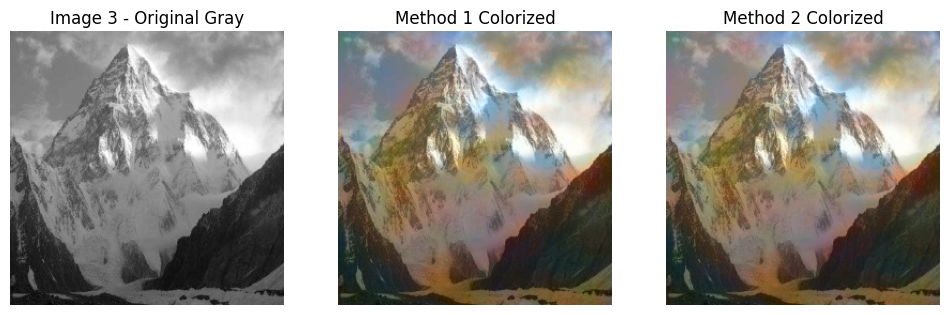

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


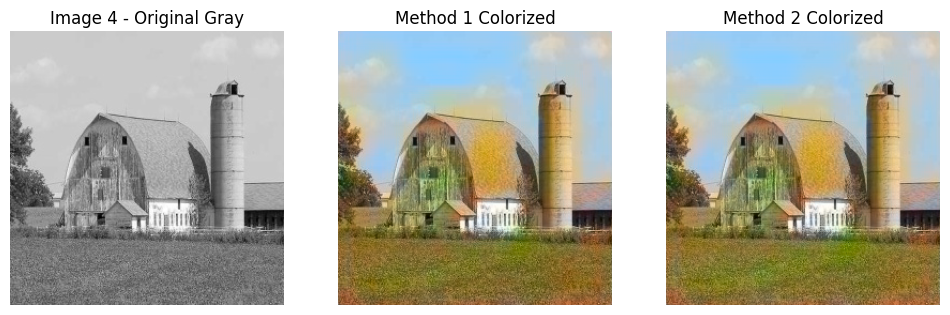

In [30]:

for idx in range(len(image_paths)):
    # Extract L channels of current image (remove channel dimension for next combination)
    L1 = X_method_1[idx][:, :, 0]
    L2 = X_method_2[idx][:, :, 0]

    # Add Batch dimension to the beginning of array to send to model
    in_1 = X_method_1[idx][np.newaxis, ...]
    in_2 = X_method_2[idx][np.newaxis, ...]


    pred_ab1 = model.predict(in_1) * 128.0
    pred_ab2 = model.predict(in_2) * 128.0


    lab_out1 = np.zeros((256, 256, 3))
    lab_out1[:, :, 0] = L1
    lab_out1[:, :, 1:] = pred_ab1

    lab_out2 = np.zeros((256, 256, 3))
    lab_out2[:, :, 0] = L2
    lab_out2[:, :, 1:] = pred_ab2


    rgb_out1 = lab2rgb(lab_out1)
    rgb_out2 = lab2rgb(lab_out2)


    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title(f"Image {idx+1} - Original Gray")
    plt.imshow(L1, cmap='gray') 
    plt.axis('off') 

    plt.subplot(1, 3, 2) 
    plt.title("Method 1 Colorized") 
    plt.imshow(rgb_out1) 
    plt.axis('off') 

    plt.subplot(1, 3, 3) 
    plt.title("Method 2 Colorized") 
    plt.imshow(rgb_out2) 
    plt.axis('off') 
    plt.show()

# 4.

### a)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


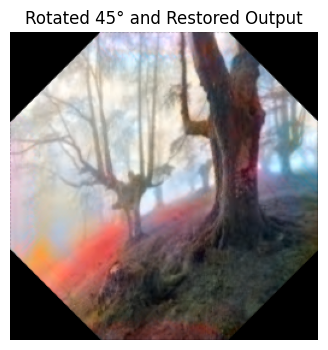

In [31]:
def rotate_image(image, angle):

    center = tuple(np.array(image.shape[1::-1]) / 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, matrix, image.shape[1::-1], flags=cv2.INTER_LINEAR)

standalone_path = 'Colorized-Img/Colorized-Img/forest.397.jpg'

img_gray = cv2.imread(standalone_path, cv2.IMREAD_GRAYSCALE)
img_gray_res = cv2.resize(img_gray, (256, 256))

# 1. Rotate the original image by 45 degrees before processing
rotated_gray = rotate_image(img_gray_res, 45)

# 2. Convert to Lab space and prepare L channel (first method)
rgb_like_rot = np.stack([rotated_gray] * 3, axis=-1) / 255.0
L_rot = rgb2lab(rgb_like_rot)[:, :, 0]
X_rot = L_rot[np.newaxis, ..., np.newaxis]

# 3. Predict colors by model
pred_ab_rot = model.predict(X_rot) * 128.0

# 4. Create Lab image and convert to rotated RGB
lab_rot = np.zeros((256, 256, 3))
lab_rot[:, :, 0] = L_rot
lab_rot[:, :, 1:] = pred_ab_rot
rgb_rot_image = lab2rgb(lab_rot)

# 5. Reverse rotation of the final output color image (-45 degrees)
restored_rgb = rotate_image((rgb_rot_image * 255).astype(np.uint8), -45) / 255.0

plt.figure(figsize=(6, 4))
plt.title("Rotated 45° and Restored Output")
plt.imshow(restored_rgb)
plt.axis('off')
plt.show()

### b)

C:\Users\reyha\AppData\Local\Temp\ipykernel_17888\3275217081.py:26: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 3 negative Z values that have been clipped to zero
  rgb_noisy_output = lab2rgb(lab_noisy)


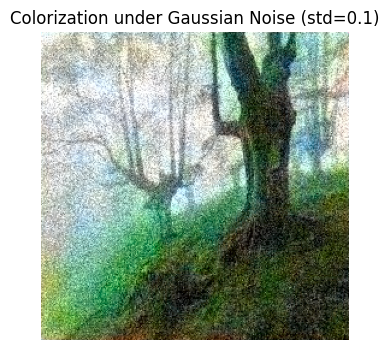

In [ ]:
standalone_path = 'Colorized-Img/Colorized-Img/forest.397.jpg'

img_gray = cv2.imread(standalone_path, cv2.IMREAD_GRAYSCALE)
img_gray_res = cv2.resize(img_gray, (256, 256))

# Convert to Lab space first method and extract L channel
rgb_like = np.stack([img_gray_res] * 3, axis=-1) / 255.0
lab_image = rgb2lab(rgb_like)
L_original = lab_image[:, :, 0] # Dimensions will be exactly (256, 256)

# Generate Gaussian noise with standard deviation 0.1 (multiply by 100 to affect the range 0 to 100)
gaussian_noise = np.random.normal(0, 0.1, L_original.shape) * 100
L_noisy = np.clip(L_original + gaussian_noise, 0, 100)


X_noisy = L_noisy.reshape((1, 256, 256, 1)).astype(np.float32)


pred_tensor = model(X_noisy, training=False)
pred_ab_noisy = pred_tensor.numpy() * 128.0


lab_noisy = np.zeros((256, 256, 3))
lab_noisy[:, :, 0] = L_noisy
lab_noisy[:, :, 1:] = pred_ab_noisy
rgb_noisy_output = lab2rgb(lab_noisy)


plt.figure(figsize=(6, 4))
plt.title("Colorization under Gaussian Noise (std=0.1)")
plt.imshow(rgb_noisy_output)
plt.axis('off')
plt.show()

### c)

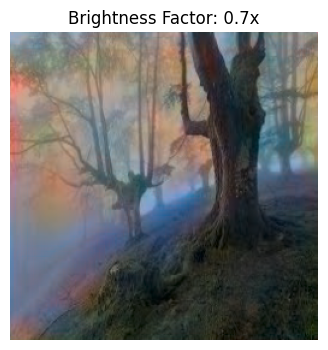

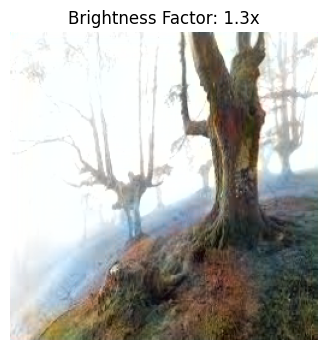

In [38]:

standalone_path = 'Colorized-Img/Colorized-Img/forest.397.jpg'


img_gray = cv2.imread(standalone_path, cv2.IMREAD_GRAYSCALE)
img_gray_res = cv2.resize(img_gray, (256, 256))


rgb_like = np.stack([img_gray_res] * 3, axis=-1) / 255.0
lab_image = rgb2lab(rgb_like)
L_base = lab_image[:, :, 0]

brightness_factors = [0.7, 1.3]

for factor in brightness_factors:

    L_modified = np.clip(L_base * factor, 0, 100)
    

    X_bright = L_modified.reshape((1, 256, 256, 1)).astype(np.float32)
    

    pred_tensor = model(X_bright, training=False)
    pred_ab_bright = pred_tensor.numpy() * 128.0
    

    lab_bright = np.zeros((256, 256, 3))
    lab_bright[:, :, 0] = L_modified
    lab_bright[:, :, 1:] = pred_ab_bright
    rgb_bright_output = lab2rgb(lab_bright)
    

    plt.figure(figsize=(5, 4))
    plt.title(f"Brightness Factor: {factor}x")
    plt.imshow(rgb_bright_output)
    plt.axis('off')
    plt.show()

##  Overall Report for Part 3



**Objective:** To evaluate a pre-trained Convolutional Autoencoder (`colorize_autoencoder_first1000.keras`) using the **CIE Lab** color space for restoring color ($a, b$ channels) to novel grayscale landscape images ($L$ channel).

---

### Preprocessing and Channel Extraction
Two methods were evaluated to extract the Lightness ($L$) channel:
* **Method 1:** Manually stacking the grayscale channel 3 times.
* **Method 2:** Direct multi-channel reading via OpenCV (`cv2.IMREAD_COLOR`).

**Finding:** Both methods produce **identical numerical outputs** and identical visual quality. However, **Method 2** is practically preferred due to better execution efficiency through OpenCV’s optimized C++ backend.

---

###  Robustness and Stability Testing

#### A) Geometric Rotation (45° Test)
* **Setup:** Pre-rotated input by $45^\circ$, colorized, and counter-rotated by $-45^\circ$.
* **Result:** The model demonstrates robust **Rotation Invariance**. Global semantic colorization (green foliage, brown trunks) remains accurate and consistent with the non-rotated baseline.

#### B) High-Frequency Distortions (Gaussian Noise Test)
* **Setup:** Added zero-mean Gaussian noise ($\sigma = 0.1$) to the $L$ channel before inference.
* **Result:** The model retains global color logic despite pixel-level graininess. 
* **Key Finding:** **Smooth, homogeneous, and bright regions** (such as foggy backgrounds and sky) are the most heavily degraded, making the noise highly visible. Conversely, **dark, textured areas** (such as tree bark and shadows) naturally mask the noise.

#### C) Luminance Variations (Brightness Test)
* **Setup:** Scaled the $L$ channel by factors of $0.7\times$ (darkening) and $1.3\times$ (brightening).
* **Result:** **Yes, colors adapt dynamically and proportionally.** * At **$0.7\times$**, the palette shifts to deeply saturated, cooler tones.
  * At **$1.3\times$**, the image exhibits realistic overexposure ("washout") in bright areas and warmer, earthy tones in shaded details, mimicking true photographic exposure.

---

###  Final Conclusion
The CIE Lab color space is highly effective for deep-learning image colorization. The model accurately extracts high-level semantic context from the Lightness channel ($L$), ensuring that the predicted chromatic components ($a, b$) dynamically and realistically adapt to geometric rotations, noise, and varied lighting environments.
